# Regularização

Este notebook apresenta as principais técnicas de regularização utilizadas em deep learning para combater o overfitting e melhorar a generalização dos modelos, incluindo uma introdução ao overfitting e sua compreensão, o uso de dropout como forma de desativação aleatória de neurônios, a aplicação de penalidades de peso L1 e L2 para controle da complexidade e indução de sparsidade, o uso de early stopping com base no desempenho em validação e estratégias de data augmentation para aumentar a diversidade dos dados.

In [1]:
import copy
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

In [2]:
device = torch.device(
    'cuda' if torch.cuda.is_available() # GPU
    else 'mps' if torch.backends.mps.is_available() # MPS (Mac Silicon)
    else 'cpu' # CPU
)
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: mps


In [3]:
# Transformação básica
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.13,), (0.31,))
])

# Carrega MNIST
train_full = torchvision.datasets.MNIST('./data', train=True, transform=transform, download=True)
test_full  = torchvision.datasets.MNIST('./data', train=False, transform=transform, download=True)

# Subconjuntos menores
train_dataset = Subset(train_full, torch.randperm(len(train_full))[:3000])
val_dataset   = Subset(test_full,  torch.randperm(len(test_full))[:1000])

print(len(train_dataset), len(val_dataset))

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128)

3000 1000


## Overfitting e Regularização

O **overfitting** ocorre quando um modelo aprende muito bem os dados de treinamento, incluindo ruído e padrões específicos, mas falha em generalizar para dados novos. Isso normalmente acontece quando a capacidade do modelo é alta em relação à quantidade (ou diversidade) de dados disponíveis.

O **bias-variance tradeoff** ajuda a entender esse comportamento:

$$
\text{Erro Total} = \text{Bias}^2 + \text{Variance} + \text{Ruído Irredutível}
$$

* **Bias**: erro por simplificação excessiva do modelo
* **Variance**: erro por sensibilidade a variações nos dados
* **Ruído Irredutível**: erro intrínseco ao problema

Nesse contexto, a **regularização** surge como um mecanismo para controlar a complexidade do modelo e reduzir o overfitting. A ideia central é impor restrições ao aprendizado, evitando que o modelo se ajuste demais aos dados de treino.

Na prática, regularização reduz a **variance** ao custo de um leve aumento de **bias**, buscando um ponto intermediário com melhor generalização. Técnicas como L2 (weight decay), L1, dropout, early stopping e data augmentation implementam essa ideia de diferentes formas, seja penalizando pesos, reduzindo dependências específicas ou aumentando a diversidade dos dados.

## Regularização L1 e L2

As regularizações **L1** e **L2** são técnicas que adicionam uma penalização aos pesos do modelo para evitar overfitting.

A ideia central:

- Penalizar pesos grandes  
- Controlar a complexidade do modelo  
- Melhorar generalização  

A função de custo passa a incluir um termo de regularização:

$$
J = L + \lambda \cdot \Omega(w)
$$

- $L$: loss original (ex: cross-entropy)  
- $\lambda$: força da regularização  
- $\Omega(w)$: termo de penalização  

### Regularização L2 (Weight Decay)

Penaliza o quadrado dos pesos:

$$
\Omega(w) = \sum_i w_i^2
$$

Novo custo:

$$
J = L + \lambda \sum_i w_i^2
$$

Efeito:

- Penaliza pesos grandes de forma suave  
- Mantém todos os pesos pequenos  
- Mais estável numericamente  

### Regularização L1

Penaliza o valor absoluto dos pesos:

$$
\Omega(w) = \sum_i |w_i|
$$

Novo custo:

$$
J = L + \lambda \sum_i |w_i|
$$

Efeito:

- Força muitos pesos a virarem exatamente zero  
- Produz modelos esparsos  

In [4]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

In [5]:
def l1_penalty(model):
    penalty = 0.0
    for p in model.parameters():
        penalty += p.abs().sum()
    return penalty

def l2_penalty(model):
    penalty = 0.0
    for p in model.parameters():
        penalty += (p ** 2).sum()
    return penalty

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [7]:
l1_lambda = 1e-5
l2_lambda = 1e-4
n_epochs = 5

train_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)

        l1 = l1_penalty(model)
        l2 = l2_penalty(model)

        loss = loss + l1_lambda * l1 + l2_lambda * l2

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{n_epochs}, Loss = {epoch_loss:.4f}")

Epoch 1/5, Loss = 1.1715
Epoch 2/5, Loss = 0.4840
Epoch 3/5, Loss = 0.3696
Epoch 4/5, Loss = 0.3189
Epoch 5/5, Loss = 0.2762


### Implementação direta no otimizador

No caso da regularização **L2**, existe um atalho muito comum no PyTorch: usar o argumento `weight_decay`:

```python
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
````

Isso evita somar a penalização manualmente à loss. Na prática, `weight_decay` costuma ser mais conveniente.

In [8]:
model_l2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_l2 = torch.optim.Adam(model_l2.parameters(), lr=1e-3, weight_decay=1e-4)

for X, y in train_loader:
    X, y = X.to(device), y.to(device)

    optimizer_l2.zero_grad()
    outputs = model_l2(X)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer_l2.step()
    break

### Adam com `weight_decay` vs AdamW

Historicamente, é comum utilizar `optim.Adam(..., weight_decay=...)`; entretanto, no caso do Adam, essa prática não corresponde exatamente à aplicação de um weight decay propriamente desacoplado, pois o termo de regularização acaba sendo incorporado à dinâmica adaptativa do próprio algoritmo.

O **AdamW** foi proposto para contornar essa limitação, ao separar explicitamente dois componentes: o passo adaptativo característico do Adam e o decaimento dos pesos. Com isso, a regularização passa a refletir de forma mais fiel o conceito clássico de weight decay, resultando, em geral, em melhor comportamento prático.

Em termos conceituais, `Adam + weight_decay` mistura a regularização com a atualização adaptativa, enquanto o `AdamW` aplica o decaimento de maneira desacoplada. Por essa razão, quando se deseja empregar weight decay em conjunto com Adam, o AdamW é, em geral, a escolha mais apropriada.

In [9]:
model_l2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_l2 = torch.optim.AdamW(model_l2.parameters(), lr=1e-3, weight_decay=1e-4)

for X, y in train_loader:
    X, y = X.to(device), y.to(device)

    optimizer_l2.zero_grad()
    outputs = model_l2(X)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer_l2.step()
    break

## Dropout

O **dropout** é uma técnica de regularização que atua desligando aleatoriamente neurônios durante o treinamento.

A ideia é:

- A cada batch, alguns neurônios são zerados com probabilidade $p$  
- Isso impede que a rede dependa demais de caminhos específicos  
- Força o modelo a aprender representações mais robustas  

Durante o treinamento:

$$
\tilde{h} = \frac{h \cdot m}{1 - p}, \quad m \sim \text{Bernoulli}(1 - p)
$$

Durante a inferência:

$$
h_{\text{test}} = h
$$

Essa versão é conhecida como **inverted dropout** e é a utilizada no PyTorch, pois mantém o valor esperado das ativações constante:

$$
\mathbb{E}[\tilde{h}] = h
$$

Dessa forma, não é necessário aplicar nenhum ajuste adicional durante a fase de avaliação.

### Dropout em treino vs inferência

Um ponto importante:

- `model.train()`: dropout ativo (zera neurônios)  
- `model.eval()`: dropout desativado  

Isso significa que o comportamento da rede muda entre treino e teste. Na inferência, usamos a rede completa, mas com escala ajustada automaticamente.

In [10]:
dropout = nn.Dropout(p=0.5)
x = torch.ones(1, 10)

dropout.train()
out_train = dropout(x)

dropout.eval()
out_eval = dropout(x)

print("Modo treino:", out_train)
print("Modo eval:", out_eval)

Modo treino: tensor([[0., 2., 2., 2., 0., 2., 0., 0., 0., 0.]])
Modo eval: tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


## Data Augmentation

Data augmentation consiste em ampliar artificialmente o conjunto de treinamento por meio de transformações aplicadas às amostras originais, preservando sua classe. Em vez de expor o modelo sempre exatamente aos mesmos exemplos, introduzimos variações plausíveis que tornam o aprendizado menos sensível a detalhes específicos de cada instância e mais voltado a padrões invariantes.

Formalmente, considere um conjunto de dados supervisionado

$$
D = \{(x_i, y_i)\}_{i=1}^{N}
$$

em que $x_i$ representa a entrada e $y_i$ seu respectivo rótulo. Definimos também um conjunto de transformações válidas

$$
\mathcal{T} = \{T_k : \mathcal{X} \to \mathcal{X} \mid y_i = y(T_k(x_i))\}
$$

isto é, transformações que modificam a entrada sem alterar sua classe semântica. A partir disso, construímos um conjunto aumentado

$$
D' = \{(T(x_i), y_i) \mid (x_i, y_i) \in D,\; T \sim \mathcal{T}\}
$$

onde, para cada exemplo original, amostramos uma transformação $T$ do conjunto $\mathcal{T}$ e geramos uma nova versão da entrada mantendo o mesmo rótulo. Em termos práticos, isso faz com que o modelo observe múltiplas variações de um mesmo padrão durante o treinamento, o que tende a reduzir overfitting e melhorar a generalização.

### torchvision.transforms

O módulo `torchvision.transforms` fornece um conjunto de transformações utilizadas para pré-processamento e data augmentation em tarefas de visão computacional.

Essas transformações podem ser encadeadas por meio de `transforms.Compose`, formando um pipeline aplicado a cada amostra durante o carregamento dos dados. Em geral, esse pipeline inclui etapas como conversão para tensor, normalização e, opcionalmente, transformações estocásticas para augmentation.

As transformações podem ser divididas em dois grupos principais. Algumas são determinísticas, como `ToTensor` e `Normalize`, sendo aplicadas da mesma forma a todas as amostras. Outras são aleatórias, como `RandomRotation`, `RandomCrop` e `RandomAffine`, introduzindo variações nos dados durante o treinamento.

Esse mecanismo é eficiente porque as transformações são aplicadas dinamicamente, sem necessidade de armazenar novas cópias dos dados. Além disso, permite controlar facilmente o comportamento do pipeline de dados, separando claramente o processamento de treino e de avaliação.

In [11]:
# Transformações de augmentation

aug_transform = T.Compose([
    T.ToPILImage(),
    
    # Geométricas
    T.RandomHorizontalFlip(p=0.2),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=45),
    T.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.8, 1.2),
        shear=10
    ),
    
    # Crop / zoom
    T.RandomResizedCrop(size=28, scale=(0.8, 1.0)),
    
    # Cor / intensidade
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))
])

/var/folders/tg/3mgj06ts3033cjmq_5nj04jm0000gp/T/ipykernel_24026/1281533936.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_original = torch.tensor(img, dtype=torch.float32) / 255.0


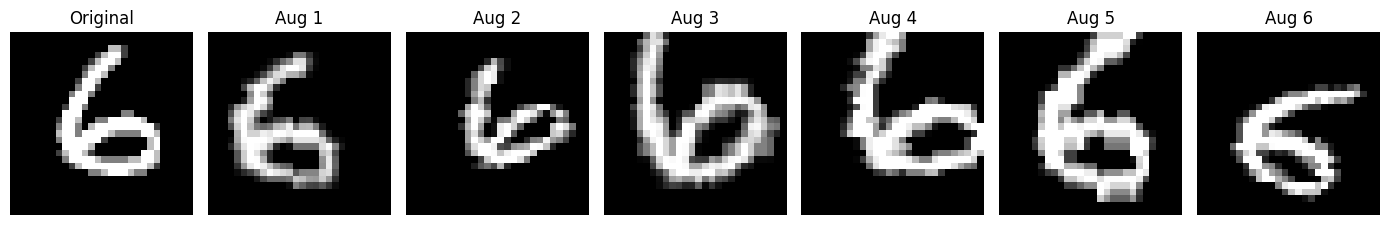

In [12]:
# Seleciona uma imagem do conjunto já carregado
dataset_base = train_loader.dataset.dataset
idx = train_loader.dataset.indices[0]

img = dataset_base.data[idx]

# Imagem original normalizada apenas para manter a mesma escala visual
img_original = torch.tensor(img, dtype=torch.float32) / 255.0
img_original = (img_original - 0.1307) / 0.3081

# Gera várias versões augmentadas da mesma imagem
augmented_images = [aug_transform(img).squeeze(0) for _ in range(6)]

fig, axes = plt.subplots(1, 7, figsize=(14, 3))

axes[0].imshow(img_original, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i, img_aug in enumerate(augmented_images, start=1):
    axes[i].imshow(img_aug, cmap="gray")
    axes[i].set_title(f"Aug {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Early Stopping

O **early stopping** é uma técnica utilizada para interromper o treinamento quando o modelo deixa de apresentar melhora em um conjunto de validação.

A ideia central é monitorar uma métrica (tipicamente a loss de validação) ao longo das épocas e encerrar o treinamento quando não há melhora por um número consecutivo de épocas, denominado *patience*.

Formalmente, seja $L_{val}^{(t)}$ a loss de validação na época $t$. O treinamento é interrompido quando:

$$
L_{val}^{(t)} \geq \min_{k < t} L_{val}^{(k)} \quad \text{por } p \text{ épocas consecutivas}
$$

onde $p$ representa o parâmetro de *patience*.

Essa estratégia atua como uma forma de regularização, pois evita que o modelo continue se ajustando ao conjunto de treino após o ponto em que começa a degradar no conjunto de validação.

Na prática, isso permite:

- reduzir overfitting  
- economizar tempo de treinamento  
- selecionar automaticamente um ponto adequado de parada  

Além disso, é comum armazenar o melhor modelo encontrado durante o treinamento, em vez de utilizar o último.

In [13]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1

        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [14]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

early_stopping = EarlyStopping(patience=2)

n_epochs = 20
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()
    train_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if early_stopping.step(val_loss, model):
        print("Early stopping ativado")
        break

# restaurar melhor modelo
early_stopping.restore_best(model)

Epoch 1 | Train Loss: 1.1565 | Val Loss: 0.5220
Epoch 2 | Train Loss: 0.4591 | Val Loss: 0.3822
Epoch 3 | Train Loss: 0.3429 | Val Loss: 0.3397
Epoch 4 | Train Loss: 0.2855 | Val Loss: 0.3124
Epoch 5 | Train Loss: 0.2502 | Val Loss: 0.3048
Epoch 6 | Train Loss: 0.2154 | Val Loss: 0.2990
Epoch 7 | Train Loss: 0.1873 | Val Loss: 0.2875
Epoch 8 | Train Loss: 0.1603 | Val Loss: 0.2793
Epoch 9 | Train Loss: 0.1382 | Val Loss: 0.2821
Epoch 10 | Train Loss: 0.1214 | Val Loss: 0.2823
Early stopping ativado


## Comparação entre Baseline e Modelo Regularizado

In [15]:
# Transformações
transform_base = T.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))
])

transform_aug = T.Compose([
    T.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=10
    ),
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))
])

# Datasets completos
train_data_base = torchvision.datasets.MNIST(
    "./data", train=True, download=True, transform=transform_base
)

train_data_aug = torchvision.datasets.MNIST(
    "./data", train=True, download=True, transform=transform_aug
)

test_data = torchvision.datasets.MNIST(
    "./data", train=False, download=True, transform=transform_base
)

# Índices fixos
train_indices = torch.randperm(len(train_data_base))[:300]
val_indices   = torch.randperm(len(test_data))[:1000]
test_indices  = torch.randperm(len(test_data))[:1000]

# Subsets
train_subset_base = Subset(train_data_base, train_indices)
train_subset_aug  = Subset(train_data_aug, train_indices)

val_subset  = Subset(test_data, val_indices)
test_subset = Subset(test_data, test_indices)

# Loaders
train_loader_base = DataLoader(train_subset_base, batch_size=32, shuffle=True)
train_loader_aug  = DataLoader(train_subset_aug, batch_size=32, shuffle=True)

val_loader  = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

print(
    f"Train: {len(train_subset_base)} | "
    f"Val: {len(val_subset)} | "
    f"Test: {len(test_subset)}"
)

Train: 300 | Val: 1000 | Test: 1000


In [16]:
myEpochs = 50

def train_model(model, train_loader, val_loader, optimizer, epochs=15, print_every=10):
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = outputs.argmax(dim=1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)

        train_loss /= len(train_loader)
        train_acc = train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)

                outputs = model(X)
                loss = criterion(outputs, y)

                val_loss += loss.item()
                preds = outputs.argmax(dim=1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if (epoch+1) % print_every == 0:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
            )

    return history

In [17]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

In [18]:
def test_model(model, test_loader):
    criterion = nn.CrossEntropyLoss()

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            test_loss += loss.item()
            preds = outputs.argmax(dim=1)
            test_correct += (preds == y).sum().item()
            test_total += y.size(0)

    test_loss /= len(test_loader)
    test_acc = test_correct / test_total

    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    return {
        "test_loss": test_loss,
        "test_acc": test_acc
    }

In [19]:
class MLP(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

Epoch 10/50 | Train Loss: 0.1616 | Train Acc: 0.9967 | Val Loss: 0.6931 | Val Acc: 0.8100
Epoch 20/50 | Train Loss: 0.0473 | Train Acc: 1.0000 | Val Loss: 0.6704 | Val Acc: 0.8030
Epoch 30/50 | Train Loss: 0.0226 | Train Acc: 1.0000 | Val Loss: 0.6727 | Val Acc: 0.7930
Epoch 40/50 | Train Loss: 0.0486 | Train Acc: 0.9933 | Val Loss: 0.7186 | Val Acc: 0.7930
Epoch 50/50 | Train Loss: 0.0108 | Train Acc: 1.0000 | Val Loss: 0.7944 | Val Acc: 0.7690
Test Loss: 0.7263 | Test Acc: 0.7730


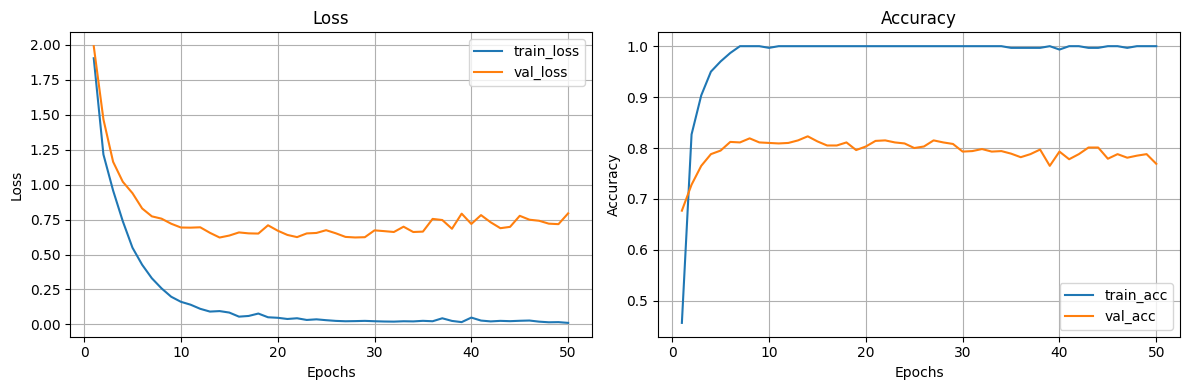

In [20]:
model_base = MLP(dropout=0.0).to(device)

optimizer_base = torch.optim.Adam(
    model_base.parameters(),
    lr=1e-3
)

history_base = train_model(
    model_base,
    train_loader_base,
    val_loader,
    optimizer_base,
    epochs=myEpochs
)
result_base = test_model(model_base, test_loader)

plot_history(history_base)

Epoch 10/50 | Train Loss: 1.5128 | Train Acc: 0.5333 | Val Loss: 1.1264 | Val Acc: 0.6790
Epoch 20/50 | Train Loss: 1.1174 | Train Acc: 0.6533 | Val Loss: 0.8090 | Val Acc: 0.7780
Epoch 30/50 | Train Loss: 1.0188 | Train Acc: 0.6433 | Val Loss: 0.6319 | Val Acc: 0.8340
Epoch 40/50 | Train Loss: 0.9581 | Train Acc: 0.6733 | Val Loss: 0.5292 | Val Acc: 0.8460
Epoch 50/50 | Train Loss: 0.6758 | Train Acc: 0.7967 | Val Loss: 0.4964 | Val Acc: 0.8560
Test Loss: 0.5035 | Test Acc: 0.8520


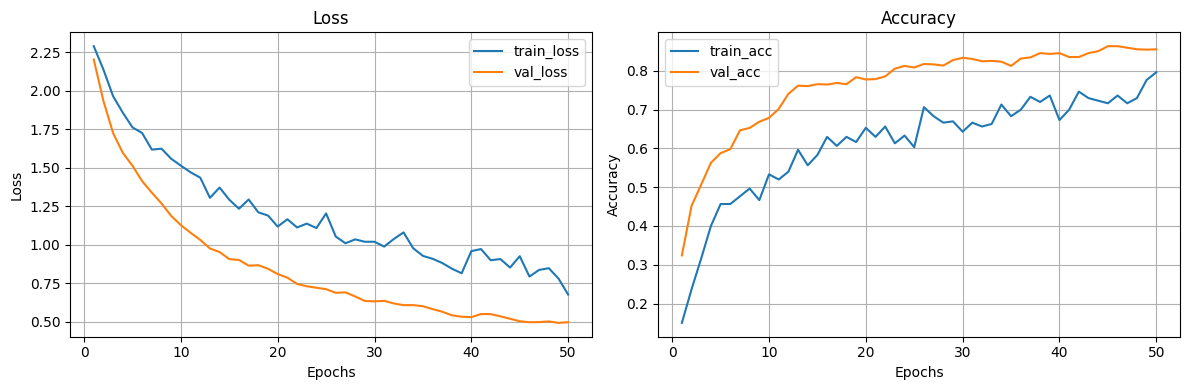

In [21]:
model_reg = MLP(dropout=0.3).to(device)

optimizer_reg = torch.optim.AdamW(
    model_reg.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

history_reg = train_model(
    model_reg,
    train_loader_aug,
    val_loader,
    optimizer_reg,
    epochs=myEpochs
)
result_reg = test_model(model_reg, test_loader)

plot_history(history_reg)

## Exercícios

### Exercício 1: Experimentação com Hyperparâmetros

Realize experimentos variando sistematicamente os valores de dropout e regularização L2 (weight decay), mantendo fixos os demais componentes do treinamento, como arquitetura, otimizador e dados; compare os resultados no conjunto de validação e teste, analise o impacto dessas escolhas no overfitting e na generalização do modelo, e identifique qual combinação de hiperparâmetros produz o melhor desempenho final.

### Exercício 2: Combinação de Transformações

Implemente diferentes estratégias de data augmentation, variando e combinando transformações como rotação, translação, escala e possíveis distorções, e avalie o efeito de cada configuração no desempenho do modelo; compare os resultados no conjunto de teste e discuta quais transformações contribuem para melhorar a generalização e quais podem prejudicar o aprendizado.

### Exercício 3: Arquitetura do Modelo

Modifique a arquitetura do modelo tornando-a progressivamente mais simples, reduzindo o número de camadas e a quantidade de neurônios por camada, e compare o desempenho obtido em cada configuração; analise a relação entre complexidade do modelo, capacidade de representação e generalização, e determine qual arquitetura apresenta o melhor equilíbrio para o conjunto de teste.